In [ ]:
from ultralytics import YOLO

# Mallin luonti
model = YOLO("yolov8n.pt")

# Koulutus
model.train(
    data="/mnt/c/Users/samul/PycharmProjects/NeuralNetworksProj/projects/datasets/licenseplate/data.yaml",
    epochs=5,
    imgsz=640,
    batch=30,
    name="license-plate-detector",
    workers=0,
    plots=False,
)

In [ ]:
# Lataa paras malli
model = YOLO("runs/detect/license-plate-detector2/weights/best.pt")

# Testaa yksittäisellä kuvalla
results = model("projects/datasets/licenseplate/valid/images/37-descarga_jpg.rf.befffeee29a7bb7e343ffffbb37e9f48.jpg")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nickyazdani/license-plate-text-recognition-dataset")

print("Path to dataset files:", path)

In [55]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.utils import pad_sequences

csv_path = "/home/stefu/.cache/kagglehub/datasets/nickyazdani/license-plate-text-recognition-dataset/versions/1/lpr.csv"
img_dir = "/home/stefu/.cache/kagglehub/datasets/nickyazdani/license-plate-text-recognition-dataset/versions/1/cropped_lps/cropped_lps"

# Merkistö: isot kirjaimet ja numerot
characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
char_to_index = {char: idx for idx, char in enumerate(characters)}
index_to_char = {idx: char for char, idx in char_to_index.items()}
num_classes = len(characters) + 1  # +1 CTC:n "blank"-merkille

def encode_label(text):
    return [char_to_index[c] for c in text.upper() if c in char_to_index]

IMG_WIDTH = 128
IMG_HEIGHT = 96

# Kuvan interpolaatiomenetelmä - vaihtoehtoja:
# cv2.INTER_NEAREST - nopein mutta heikkolaatuisin
# cv2.INTER_LINEAR - hyvä kompromissi nopeuden ja laadun välillä (oletus)
# cv2.INTER_CUBIC - parempi laatu mutta hitaampi
# cv2.INTER_LANCZOS4 - parhaita laatuja, mutta hitain
INTERPOLATION = cv2.INTER_CUBIC  # Käytetään kuutiointerpolaatiota parempaan upscaleen

images, labels, label_lengths = [], [], []
skipped_count = 0
success_count = 0

# Lue CSV-tiedosto
df = pd.read_csv(csv_path)

def contrast_stretching(image):
    min_val = np.min(image)
    max_val = np.max(image)
    stretched_image = (image - min_val) * (255 / (max_val - min_val))
    return stretched_image.astype(np.uint8)  # Muuta uint8-muotoon

for idx, row in df.iterrows():
    try:
        img_path = os.path.join(img_dir, row["images"])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Kuvaa ei löytynyt: {img_path}")
            skipped_count += 1
            continue

        # Suorita kontrastin venytys
        img = contrast_stretching(img)

        # Gaussian blur
        img = cv2.GaussianBlur(img, (5, 5), 0)  # (5, 5) on suodattimen koko, 0 on sigma-arvo

        # Muutetaan kuvan koko
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=INTERPOLATION)

        # Normaalisoi kuva (0-1 skaalalle)
        img = (img - np.min(img)) / (np.max(img) - np.min(img))

        # Muuta takaisin 8-bittiseksi uint8-kuvaksi
        img = (img * 255).astype(np.uint8)

        img = np.expand_dims(img, axis=-1)  # (96, 128, 1)

        images.append(img)

        encoded = encode_label(row["labels"])
        labels.append(encoded)
        label_lengths.append(len(encoded))

        success_count += 1

        if (idx + 1) % 100 == 0:
            print(f"Käsitelty {idx + 1} kuvaa, onnistuneita: {success_count}, ohitettuja: {skipped_count}")

    except Exception as e:
        print(f"Virhe käsiteltäessä kuvaa {row['images']}: {str(e)}")
        skipped_count += 1

print(f"Käsittely valmis! Yhteensä käsitelty {success_count} kuvaa, ohitettu {skipped_count} kuvaa.")

# Tarkista, onko onnistuneita kuvia
if not images:
    print("Ei onnistuneesti ladattuja kuvia! Tarkista tiedostopolut.")
    exit(1)

# Täydennä labelit pituuteen max_label_len
max_label_len = max(label_lengths)
padded_labels = pad_sequences(labels, maxlen=max_label_len, value=-1, padding="post")

X = np.array(images)  # (samples, 96, 128, 1)
y = np.array(padded_labels)

print(f"Datasetin koko: {X.shape[0]} kuvaa, mitat: {X.shape[1:]} pikseleissä")
print(f"Pisimmän labelin pituus: {max_label_len}")

X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    X, y, label_lengths, test_size=0.2, random_state=42
)

train_input_len = np.full((len(X_train), 1), IMG_WIDTH // 8, dtype=np.int32)
val_input_len = np.full((len(X_val), 1), IMG_WIDTH // 8, dtype=np.int32)

Käsitelty 100 kuvaa, onnistuneita: 100, ohitettuja: 0
Käsitelty 200 kuvaa, onnistuneita: 200, ohitettuja: 0
Käsitelty 300 kuvaa, onnistuneita: 300, ohitettuja: 0
Käsitelty 400 kuvaa, onnistuneita: 400, ohitettuja: 0
Käsitelty 500 kuvaa, onnistuneita: 500, ohitettuja: 0
Käsitelty 600 kuvaa, onnistuneita: 600, ohitettuja: 0
Käsitelty 700 kuvaa, onnistuneita: 700, ohitettuja: 0
Käsitelty 800 kuvaa, onnistuneita: 800, ohitettuja: 0
Käsitelty 900 kuvaa, onnistuneita: 900, ohitettuja: 0
Käsitelty 1000 kuvaa, onnistuneita: 1000, ohitettuja: 0
Käsitelty 1100 kuvaa, onnistuneita: 1100, ohitettuja: 0
Käsitelty 1200 kuvaa, onnistuneita: 1200, ohitettuja: 0
Käsitelty 1300 kuvaa, onnistuneita: 1300, ohitettuja: 0
Käsitelty 1400 kuvaa, onnistuneita: 1400, ohitettuja: 0
Käsitelty 1500 kuvaa, onnistuneita: 1500, ohitettuja: 0
Käsitelty 1600 kuvaa, onnistuneita: 1600, ohitettuja: 0
Käsitelty 1700 kuvaa, onnistuneita: 1700, ohitettuja: 0
Käsitelty 1800 kuvaa, onnistuneita: 1800, ohitettuja: 0
Käsitelty 

In [56]:
print(X.shape)
print(X_train.shape)
print(X_val.shape)

(20000, 96, 128, 1)
(16000, 96, 128, 1)
(4000, 96, 128, 1)


In [57]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Reshape, Dense, Dropout, BatchNormalization, Activation
from keras.layers import Bidirectional, LSTM
from keras.layers import Lambda
from keras._tf_keras.keras.callbacks import EarlyStopping
import os
import tensorflow as tf

os.environ["KERAS_BACKEND"] = "tensorflow"


# Määritellään tärkeät parametrit
img_height, img_width, img_channels = 96, 128, 1
num_classes = 36 + 1  # 26 kirjainta + 10 numeroa + CTC-blank

# Syötekuva
input_img = Input(shape=(img_height, img_width, img_channels), name='image_input')

## CNN Feature extractor
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(input_img)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)  # -> (48, 64)

x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)  # -> (24, 32)

x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)  # -> (12, 16)

x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# Ei poolingia tässä — säilytetään enemmän "aikaa"

# Muodosta sekvenssi aikadimensiossa (width)
# Muoto: (batch, height, width, channels) → (batch, width, height × channels)
new_shape = (x.shape[2], x.shape[1] * x.shape[3])  # (W, H*C)
x = Reshape(target_shape=new_shape)(x)

# 2x Bidirectional LSTM
x = Bidirectional(LSTM(256, return_sequences=True))(x)
x = Dropout(0.25)(x)
x = Bidirectional(LSTM(256, return_sequences=True))(x)

# Jokaiselle aikastepille merkki (softmax yli kirjainten ja numeroiden)
x = Dense(num_classes, activation='softmax')(x)

# Malli
model = Model(inputs=input_img, outputs=x)
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 96, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 96, 128, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 48, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 48, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 24, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 16, 6144)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 16, 512)        │    13,109,248 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 16, 512)        │     1,574,912 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16, 37)         │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,256,805 (62.01 MB)

 Trainable params: 16,254,885 (62.01 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [58]:
# Placeholderit CTC:lle
labels = Input(name='label', shape=(6,), dtype='int32')
input_length = Input(name='input_length', shape=(1,), dtype='int32')  # output sequence length
label_length = Input(name='label_length', shape=(1,), dtype='int32')  # always 6

# CTC-loss
def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

# Output of the Lambda layer
loss_out = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc_loss')(
    [x, labels, input_length, label_length]
)

# Lopullinen training-malli
ctc_model = Model(inputs=[input_img, labels, input_length, label_length], outputs=loss_out)

# Kompiloi malli, määrittele loss funktio CTC:lle
ctc_model.compile(
    optimizer='adam',
    loss=lambda y_true, y_pred: y_pred  # Käytä Lambda-kerroksen määrittelemää CTC-häviötä
)

# Muotoile data
train_input_len = train_input_len.astype(np.int32)
val_input_len = val_input_len.astype(np.int32)

train_data = {
    'image_input': X_train,
    'label': y_train,
    'input_length': train_input_len,
    'label_length': np.expand_dims(len_train, axis=1)
}
val_data = {
    'image_input': X_val,
    'label': y_val,
    'input_length': val_input_len,
    'label_length': np.expand_dims(len_val, axis=1)
}

# Dummy-arvot ilman sanakirjaa
train_dummy_y = np.zeros((len(X_train), 1), dtype=np.float32)
val_dummy_y = np.zeros((len(X_val), 1), dtype=np.float32)


early_stopping = EarlyStopping(monitor='val_loss', patience=2)

# Suorita koulutus
ctc_model.fit(
    x=train_data,
    y=train_dummy_y,
    validation_data=(val_data, val_dummy_y),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - loss: 20.4435 - val_loss: 19.4377
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - loss: 19.3175 - val_loss: 18.3070
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - loss: 17.4312 - val_loss: 15.2427
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - loss: 14.0379 - val_loss: 11.6335
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - loss: 10.1072 - val_loss: 7.5623
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - loss: 6.4179 - val_loss: 5.2622
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - loss: 4.1051 - val_loss: 4.3930
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - loss: 2.8683 - val_loss: 3.8217
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - loss: 2.0887 - val_loss: 3.6005
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - loss: 1.5197 - val_loss: 3.6326
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: 1.2095 - val_loss: 3.7979


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Image 1: NXVRQW
True label: NXVRQW


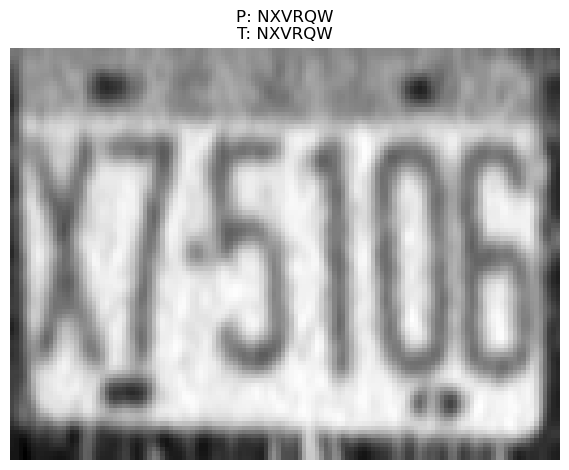

Image 2: XVSX6B
True label: XVSX6B


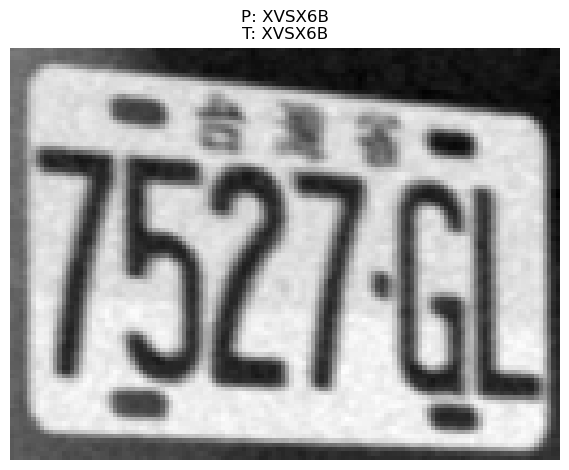

Image 3: 6VVRWQ
True label: 6VVRYQ


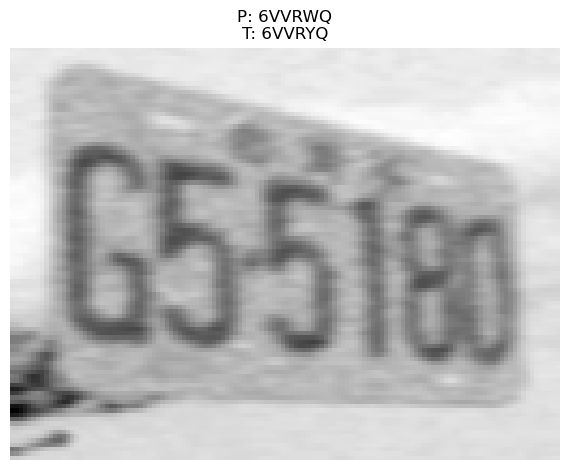

Image 4: TYUZJK
True label: TYUZJK


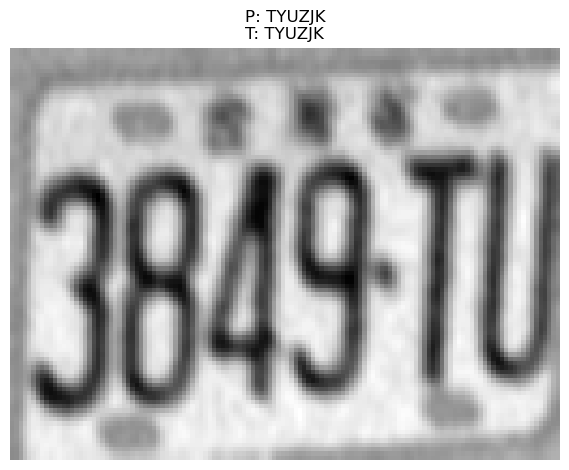

Image 5: JXYXYW
True label: JXYXYW


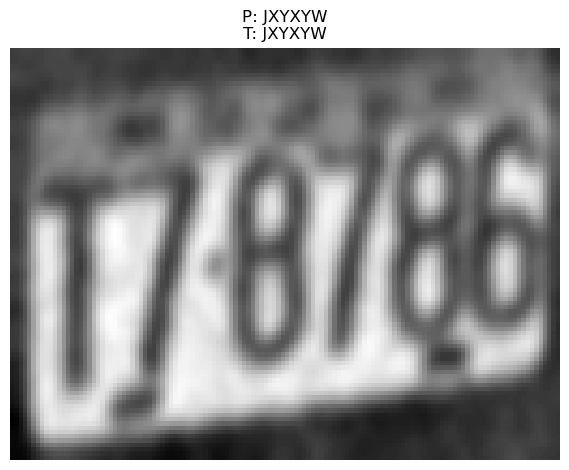

Image 6: VQTUJ
True label: AZVQQQ


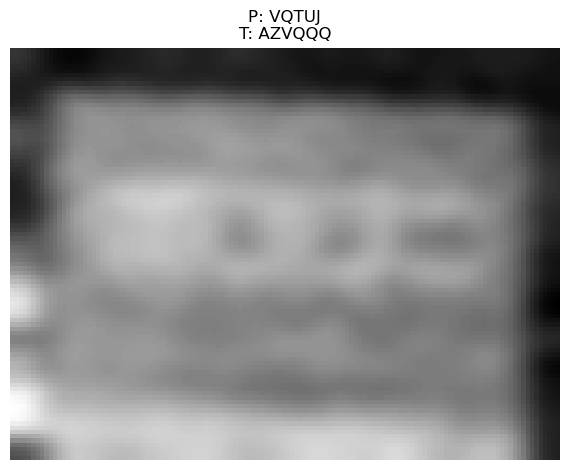

Image 7: VZVSKM
True label: VZVS3M


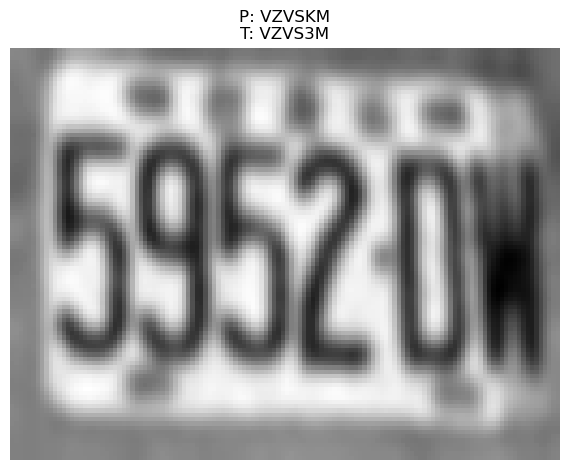

Image 8: QSQW6C
True label: QSQWA5


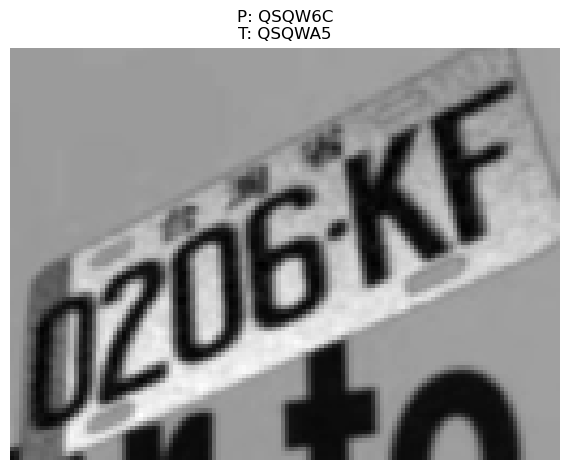

Image 9: DXYXWQ
True label: DXYXWQ


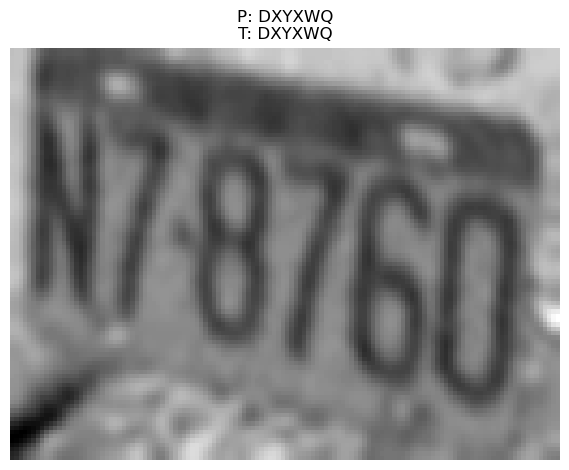

Image 10: XTVZ4A
True label: XTVZPA


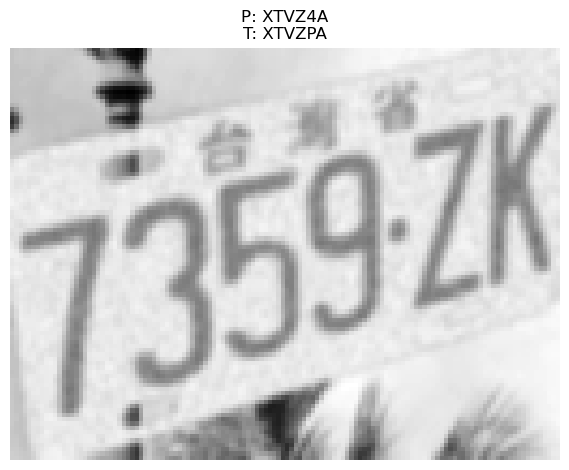

In [63]:
import matplotlib.pyplot as plt

characters = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'

def decode_sequence(seq):
    return ''.join([characters[i] for i in seq if i != -1])

# Varmista että sample_imgs ja sample_labels vastaavat preds-rivejä
sample_imgs = X_val[:10]
sample_labels = y_val[:10]

print()


preds = model.predict(sample_imgs)
decoded, _ = tf.keras.backend.ctc_decode(preds, input_length=np.ones(preds.shape[0]) * preds.shape[1], greedy=True)
decoded_sequences = decoded[0].numpy()

for i in range(10):
    img = sample_imgs[i].squeeze()
    prediction = decode_sequence(decoded_sequences[i])
    ground_truth = decode_sequence(sample_labels[i])

    print(f"Image {i+1}: {prediction}")
    print(f"True label: {ground_truth}")

    plt.imshow(img, cmap='gray')
    plt.title(f"P: {prediction}\nT: {ground_truth}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()